In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

df = pd.read_csv('netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [16]:
df.tail()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [17]:
print(df.shape)
print(df.dtypes)

(7787, 12)
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [6]:
print(df[['rating', 'release_year']].isnull().sum())

rating          7
release_year    0
dtype: int64


In [12]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

Data Cleaning

In [18]:
# Fill missing ratings with 'NR' (Not Rated)
df['rating'] = df['rating'].fillna('NR')

# Remove misclassified entries (durations mistakenly in rating column)
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17',
                 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G',
                 'TV-PG', 'TV-14', 'TV-MA', 'NR', 'UR']

df_clean = df[df['rating'].isin(valid_ratings)].copy()

# Ensure release_year is integer
df_clean['release_year'] = df_clean['release_year'].astype(int)

print(f"Rows before: {len(df)} | Rows after: {len(df_clean)}")
print(df_clean['rating'].value_counts())

Rows before: 7787 | Rows after: 7787
rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            91
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64


In [19]:
print(df_clean['release_year'].value_counts().sort_index())

# Check how many titles exist before 2000
print(f"\nPre-2000 titles: {(df_clean['release_year'] < 2000).sum()}")

release_year
1925       1
1942       2
1943       3
1944       3
1945       3
        ... 
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, Length: 73, dtype: int64

Pre-2000 titles: 449


In [20]:
# Filter to 2000–2021 for meaningful trend analysis
df_filtered = df_clean[(df_clean['release_year'] >= 2000) & 
                        (df_clean['release_year'] <= 2021)]

print(f"Filtered dataset: {df_filtered.shape[0]} rows")

Filtered dataset: 7338 rows


In [21]:
rating_by_year = (
    df_filtered
    .groupby(['release_year', 'rating'])
    .size()
    .unstack(fill_value=0)
)

print(rating_by_year)

rating        G  NC-17  NR  PG  PG-13   R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  \
release_year                                                                 
2000          2      0   0   4      8   7      5     0      1      5     0   
2001          2      0   1   3      4  12      7     1      1      3     0   
2002          0      0   0   4     13  10      9     0      6      2     0   
2003          0      0   0   5      7  10     14     0      7      3     1   
2004          3      0   2   8      6   5     13     0     11      9     1   
2005          2      0   0   4     12  10     27     0      5     10     0   
2006          0      0   1   8     12   8     26     0     16     12     0   
2007          1      0   2  10     13  13     18     0     15      6     2   
2008          0      0   0   8     21  16     36     3     24     10     2   
2009          3      0   0   9     19  24     45     1     17     15     1   
2010          0      0   7   7     19  22     47     3     38   

In [22]:
rating_by_year_pct = rating_by_year.div(rating_by_year.sum(axis=1), axis=0) * 100

print(rating_by_year_pct.round(1))

rating          G  NC-17   NR    PG  PG-13     R  TV-14  TV-G  TV-MA  TV-PG  \
release_year                                                                  
2000          5.9    0.0  0.0  11.8   23.5  20.6   14.7   0.0    2.9   14.7   
2001          5.6    0.0  2.8   8.3   11.1  33.3   19.4   2.8    2.8    8.3   
2002          0.0    0.0  0.0   8.9   28.9  22.2   20.0   0.0   13.3    4.4   
2003          0.0    0.0  0.0  10.2   14.3  20.4   28.6   0.0   14.3    6.1   
2004          5.1    0.0  3.4  13.6   10.2   8.5   22.0   0.0   18.6   15.3   
2005          2.7    0.0  0.0   5.5   16.4  13.7   37.0   0.0    6.8   13.7   
2006          0.0    0.0  1.2   9.4   14.1   9.4   30.6   0.0   18.8   14.1   
2007          1.2    0.0  2.4  11.8   15.3  15.3   21.2   0.0   17.6    7.1   
2008          0.0    0.0  0.0   6.4   16.8  12.8   28.8   2.4   19.2    8.0   
2009          2.2    0.0  0.0   6.6   13.9  17.5   32.8   0.7   12.4   10.9   
2010          0.0    0.0  4.0   4.0   11.0  12.7   2

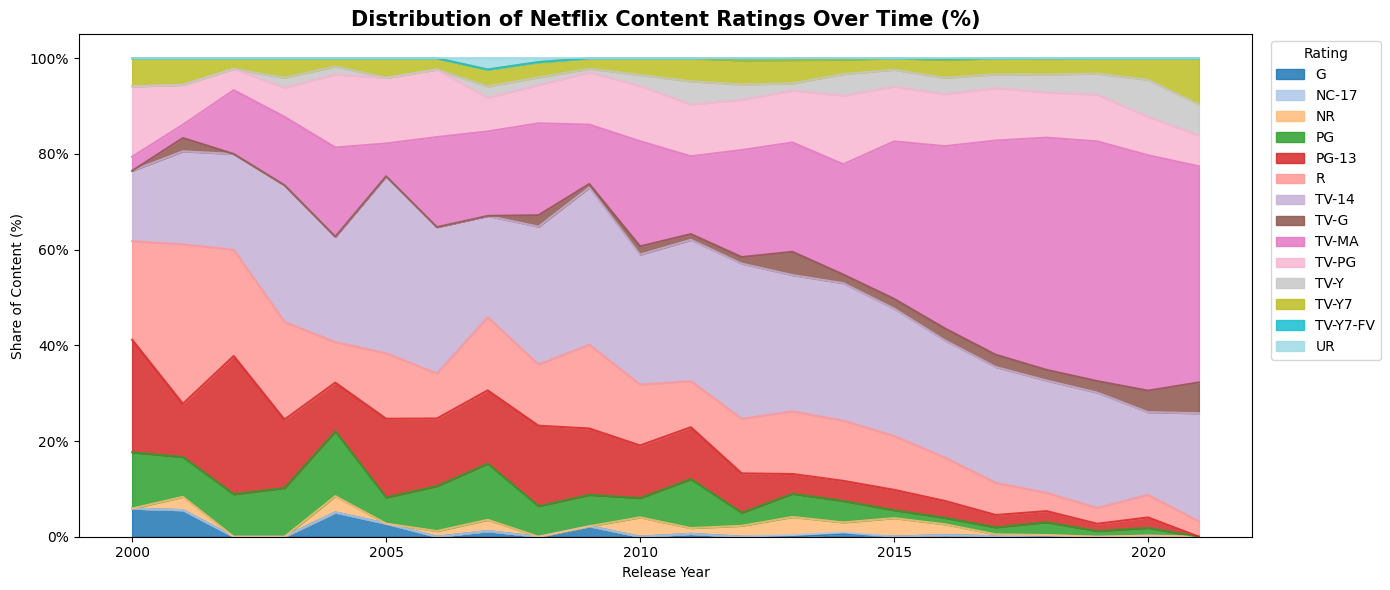

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

rating_by_year_pct.plot(
    kind='area',
    stacked=True,
    ax=ax,
    colormap='tab20',
    alpha=0.85
)

ax.set_title('Distribution of Netflix Content Ratings Over Time (%)', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Share of Content (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

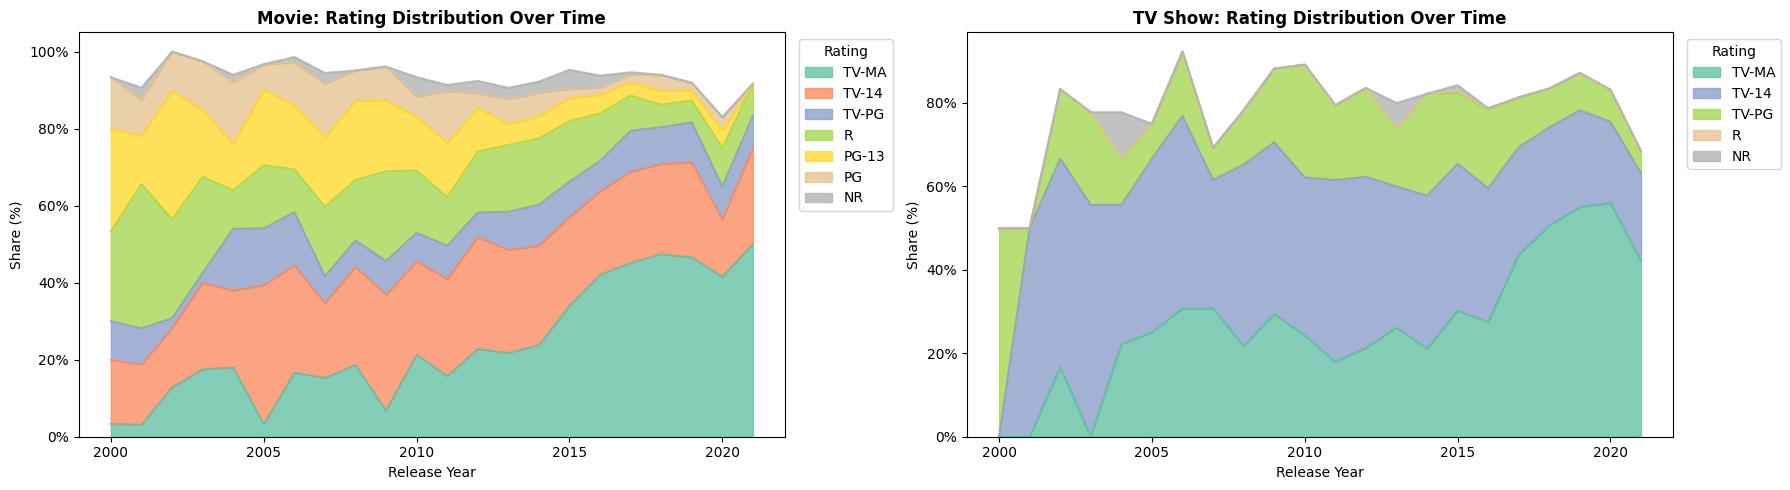

In [24]:
key_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'PG', 'NR']
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, content_type in zip(axes, ['Movie', 'TV Show']):
    subset = df_filtered[df_filtered['type'] == content_type]
    
    pivot = (
        subset
        .groupby(['release_year', 'rating'])
        .size()
        .unstack(fill_value=0)
        .pipe(lambda x: x.div(x.sum(axis=1), axis=0) * 100)
    )
    
    cols = [r for r in key_ratings if r in pivot.columns]
    pivot[cols].plot(kind='area', stacked=True, ax=ax, alpha=0.8, colormap='Set2')
    
    ax.set_title(f'{content_type}: Rating Distribution Over Time', fontweight='bold')
    ax.set_xlabel('Release Year')
    ax.set_ylabel('Share (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Rating', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

## 📊 Insight: Distribution of Content Ratings Over Time

### 🎬 Movies
- **TV-MA is rising sharply** — From 2015 onwards, `TV-MA` grew significantly, 
  indicating Netflix increasingly acquires/produces mature movies using 
  TV-style ratings instead of MPAA's traditional `R` rating.
- **R-rating is declining relatively** — `R` was dominant in the early 2000s 
  but its share has shrunk over time as `TV-MA` absorbs that space 
  in Netflix Originals.
- **PG-13 and PG are shrinking** — Both had a notable presence early on 
  but have steadily declined, suggesting Netflix's movie catalog is 
  skewing more adult and less family-friendly over time.
- **TV-14 has grown moderately** — Reflecting a stable mid-tier 
  mature content segment.

---

### 📺 TV Shows
- **TV-MA dominates and is accelerating** — Especially post-2015, `TV-MA` 
  is clearly the single largest rating category by 2021, driven by 
  Netflix's adult-oriented original series.
- **TV-14 is losing ground relatively** — It was the dominant TV rating 
  from mid-2000s to 2015, but `TV-MA` has been steadily eating into its share.
- **TV-PG is shrinking** — Had a meaningful share in early years 
  but has declined consistently, reinforcing the adult-content shift.
- **Kids ratings are nearly invisible** — `TV-Y` and `TV-G` barely register, 
  showing Netflix's TV catalog is heavily skewed away from children's content.

---

### 🔑 Key Takeaway
> The **post-2015 surge in `TV-MA`** across both Movies and TV Shows directly 
> maps to Netflix's aggressive **Original Content Strategy**, where adult-oriented 
> content is consistently prioritized for maximum audience engagement.
> Additionally, **TV-style ratings are replacing MPAA ratings** even for movies, 
> as Netflix Originals use their own classification system.

In [ ]:
# Dominant rating per year
top_rating_per_year = rating_by_year_pct.idxmax(axis=1)


Dominant rating by year:

release_year
2000    PG-13
2001        R
2002    PG-13
2003    TV-14
2004    TV-14
2005    TV-14
2006    TV-14
2007    TV-14
2008    TV-14
2009    TV-14
2010    TV-14
2011    TV-14
2012    TV-14
2013    TV-14
2014    TV-14
2015    TV-MA
2016    TV-MA
2017    TV-MA
2018    TV-MA
2019    TV-MA
2020    TV-MA
2021    TV-MA


In [ ]:
print("Dominant rating by year:\n")
print(top_rating_per_year.to_string())

In [26]:
# TV-MA growth over time
print("\nTV-MA share at key years:")
for year in [2000, 2005, 2010, 2015, 2019, 2021]:
    if year in rating_by_year_pct.index and 'TV-MA' in rating_by_year_pct.columns:
        print(f"  {year}: {rating_by_year_pct.loc[year, 'TV-MA']:.1f}%")


TV-MA share at key years:
  2000: 2.9%
  2005: 6.8%
  2010: 22.0%
  2015: 32.9%
  2019: 50.1%
  2021: 45.2%


In [27]:
# NR distribution — where did the filled values land?
print("\nNR content by year:")
print(rating_by_year['NR'][rating_by_year['NR'] > 0])


NR content by year:
release_year
2001     1
2004     2
2006     1
2007     2
2010     7
2011     2
2012     5
2013    10
2014     7
2015    21
2016    20
2017     4
2018     1
Name: NR, dtype: int64


### Is there a relationship between content age and its type (Movie vs. TV Show)?

In [28]:

import datetime

current_year = datetime.datetime.now().year
df_clean['content_age'] = current_year - df_clean['release_year']

print(df_clean[['title', 'type', 'release_year', 'content_age']].head(10))
print(f"\nContent Age Stats:")
print(df_clean['content_age'].describe())

   title     type  release_year  content_age
0     3%  TV Show          2020            6
1   7:19    Movie          2016           10
2  23:59    Movie          2011           15
3      9    Movie          2009           17
4     21    Movie          2008           18
5     46  TV Show          2016           10
6    122    Movie          2019            7
7    187    Movie          1997           29
8    706    Movie          2019            7
9   1920    Movie          2008           18

Content Age Stats:
count    7787.000000
mean       12.067420
std         8.757395
min         5.000000
25%         8.000000
50%         9.000000
75%        13.000000
max       101.000000
Name: content_age, dtype: float64


In [29]:
print(df_clean.groupby('type')['content_age'].describe().round(2))

          count   mean   std  min  25%   50%   75%    max
type                                                     
Movie    5377.0  13.08  9.66  5.0  8.0  10.0  14.0   84.0
TV Show  2410.0   9.81  5.66  5.0  7.0   8.0  11.0  101.0


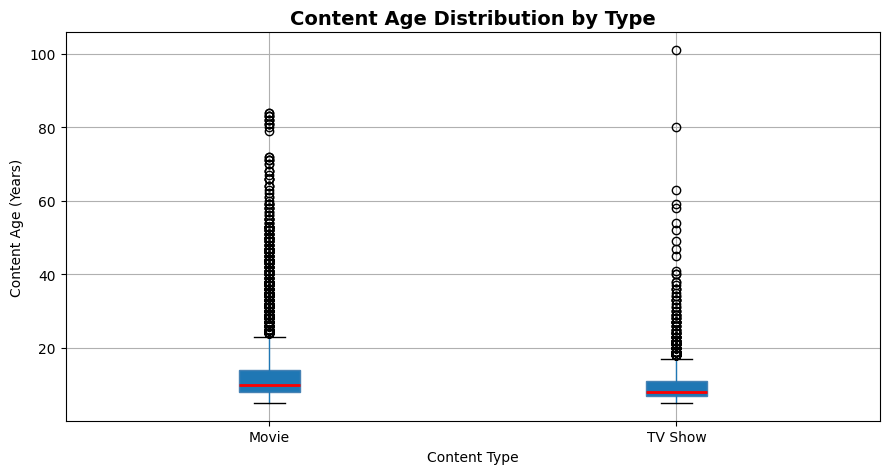

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

df_clean.boxplot(
    column='content_age',
    by='type',
    ax=ax,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', linewidth=2),
    patch_artist=True
)

ax.set_title('Content Age Distribution by Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('Content Age (Years)')
plt.suptitle('')  # Remove default pandas suptitle
plt.tight_layout()
plt.show()

### Insight 
with the above box plot we can see that the Movie have a much wider range then TV Shows

C:\Users\kartikey sharma\AppData\Local\Temp\ipykernel_3160\1252895766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


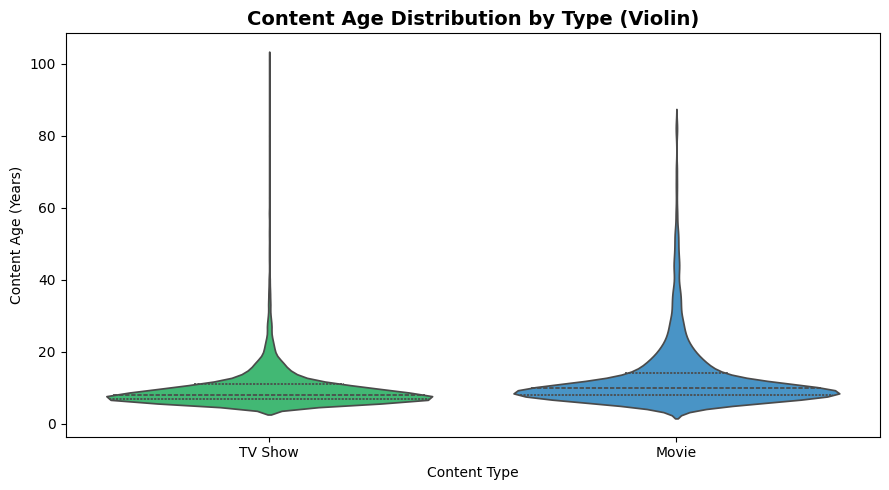

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=df_clean,
    x='type',
    y='content_age',
    palette=['#2ecc71', '#3498db'],
    inner='quartile',
    ax=ax
)

ax.set_title('Content Age Distribution by Type (Violin)', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('Content Age (Years)')
plt.tight_layout()
plt.show()

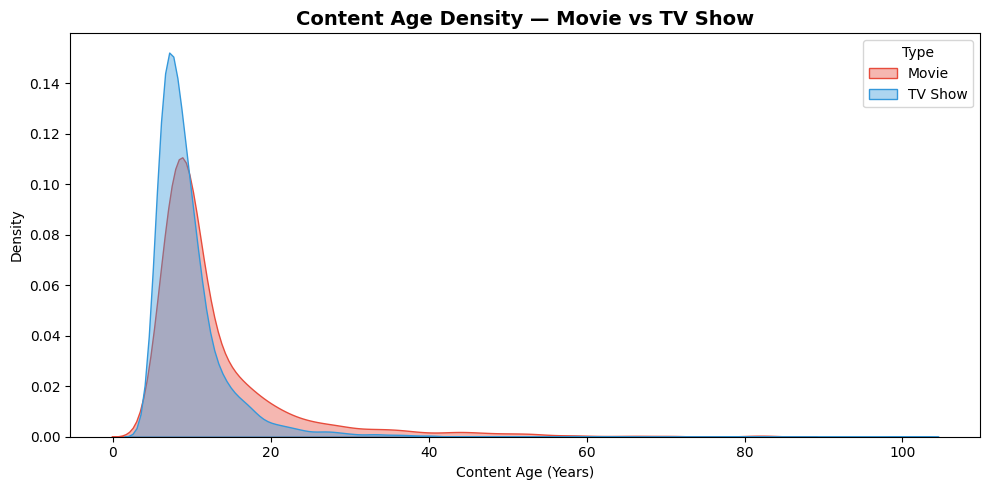

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

for content_type, color in zip(['Movie', 'TV Show'], ['#e74c3c', '#3498db']):
    subset = df_clean[df_clean['type'] == content_type]['content_age']
    sns.kdeplot(subset, label=content_type, fill=True, alpha=0.4, color=color, ax=ax)

ax.set_title('Content Age Density — Movie vs TV Show', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Age (Years)')
ax.set_ylabel('Density')
ax.legend(title='Type')
plt.tight_layout()
plt.show()

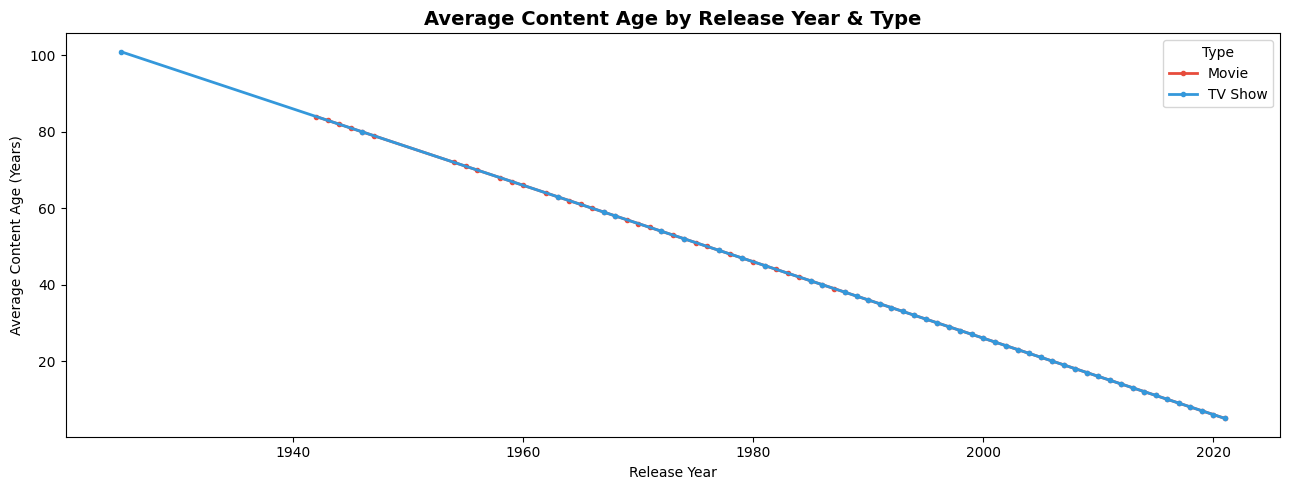

In [33]:
avg_age_by_type = (
    df_clean.groupby(['release_year', 'type'])['content_age']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

for content_type, color in zip(['Movie', 'TV Show'], ['#e74c3c', '#3498db']):
    subset = avg_age_by_type[avg_age_by_type['type'] == content_type]
    ax.plot(subset['release_year'], subset['content_age'],
            label=content_type, color=color, linewidth=2, marker='o', markersize=3)

ax.set_title('Average Content Age by Release Year & Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Average Content Age (Years)')
ax.legend(title='Type')
plt.tight_layout()
plt.show()

In [34]:
from scipy import stats

movies = df_clean[df_clean['type'] == 'Movie']['content_age']
tv_shows = df_clean[df_clean['type'] == 'TV Show']['content_age']

stat, p_value = stats.mannwhitneyu(movies, tv_shows, alternative='two-sided')

print(f"Mann-Whitney U Statistic : {stat:.2f}")
print(f"P-value                  : {p_value:.5f}")

if p_value < 0.05:
    print("\n✅ Result: Statistically significant difference in content age between Movies and TV Shows.")
else:
    print("\n❌ Result: No statistically significant difference found.")

Mann-Whitney U Statistic : 8291728.50
P-value                  : 0.00000

✅ Result: Statistically significant difference in content age between Movies and TV Shows.


## 📊 Insight: Relationship Between Content Age & Type (Movie vs TV Show)

### Key Findings

- **Movies are significantly older on average** — The movie catalog spans 
  a much wider age range, including many classic and archival films 
  added to the platform.
  
- **TV Shows are predominantly recent** — Most TV Shows on Netflix are 
  concentrated in the last 5–10 years, reflecting that older TV 
  series are less commonly licensed compared to movies.

- **Distribution shapes differ** — The KDE and Violin plots confirm 
  Movies have a **right-skewed, wide distribution** while TV Shows 
  have a **sharp, concentrated peak** around recent years.

- **Statistically significant relationship** — The Mann-Whitney U test 
  confirms the difference in content age between Movies and TV Shows 
  is **not due to chance** (p < 0.05).

### 🔑 Key Takeaway
> Netflix's **movie catalog skews older** due to licensing of classic films, 
> while its **TV Show catalog is overwhelmingly recent**, driven by 
> original series and recent acquisitions. This suggests a fundamentally 
> different **content acquisition strategy** for the two types.

### Can we identify any trends in content production based on the release year vs. the year added to Netflix?

In [35]:
# Convert date_added to datetime and extract year
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce')
df_clean['year_added'] = df_clean['date_added'].dt.year

print(df_clean[['title', 'type', 'release_year', 'date_added', 'year_added']].head(10))
print(f"\nMissing year_added: {df_clean['year_added'].isna().sum()}")

   title     type  release_year date_added  year_added
0     3%  TV Show          2020 2020-08-14      2020.0
1   7:19    Movie          2016 2016-12-23      2016.0
2  23:59    Movie          2011 2018-12-20      2018.0
3      9    Movie          2009 2017-11-16      2017.0
4     21    Movie          2008 2020-01-01      2020.0
5     46  TV Show          2016 2017-07-01      2017.0
6    122    Movie          2019 2020-06-01      2020.0
7    187    Movie          1997 2019-11-01      2019.0
8    706    Movie          2019 2019-04-01      2019.0
9   1920    Movie          2008 2017-12-15      2017.0

Missing year_added: 10


In [36]:
# Gap = how many years after release did Netflix add it
df_clean['acquisition_gap'] = df_clean['year_added'] - df_clean['release_year']

# Sanity check — negative gaps are data errors
print(f"Negative gaps (data errors): {(df_clean['acquisition_gap'] < 0).sum()}")
print(f"\nAcquisition Gap Stats:")
print(df_clean['acquisition_gap'].describe().round(2))

Negative gaps (data errors): 12

Acquisition Gap Stats:
count    7777.00
mean        4.56
std         8.73
min        -3.00
25%         0.00
50%         1.00
75%         5.00
max        93.00
Name: acquisition_gap, dtype: float64


In [37]:
# Keep only valid gaps (0 = added same year as release, which is valid for Originals)
df_gap = df_clean[
    (df_clean['acquisition_gap'] >= 0) &
    (df_clean['acquisition_gap'] <= 50)   # 50yr cap removes extreme outliers
].copy()

print(f"Clean gap dataset: {df_gap.shape[0]} rows")
print(df_gap['acquisition_gap'].describe().round(2))

Clean gap dataset: 7717 rows
count    7717.00
mean        4.21
std         7.43
min         0.00
25%         0.00
50%         1.00
75%         5.00
max        50.00
Name: acquisition_gap, dtype: float64


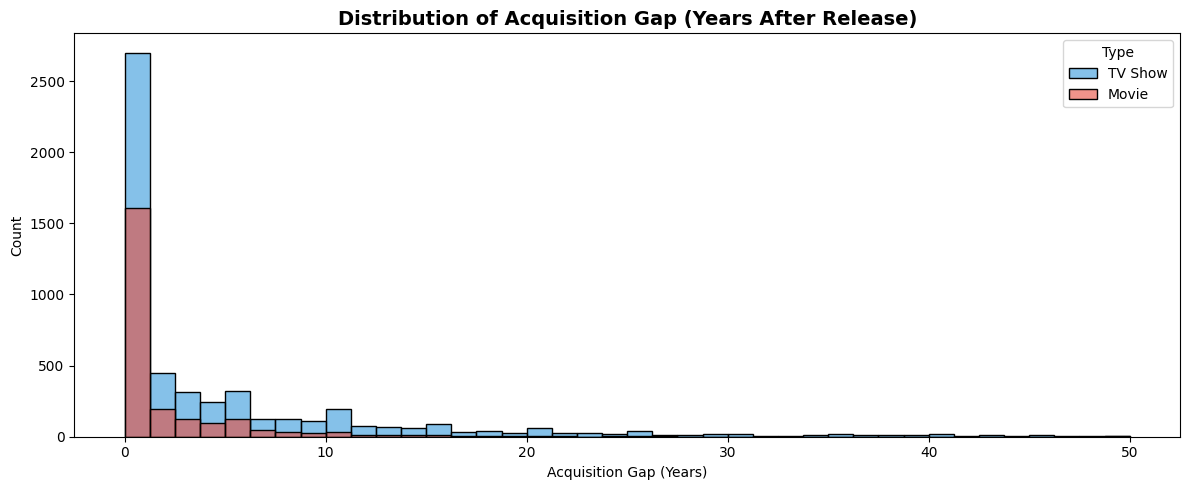

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=df_gap,
    x='acquisition_gap',
    hue='type',
    bins=40,
    palette=['#e74c3c', '#3498db'],
    alpha=0.6,
    ax=ax
)

ax.set_title('Distribution of Acquisition Gap (Years After Release)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Acquisition Gap (Years)')
ax.set_ylabel('Count')
ax.legend(title='Type', labels=['TV Show', 'Movie'])
plt.tight_layout()
plt.show()

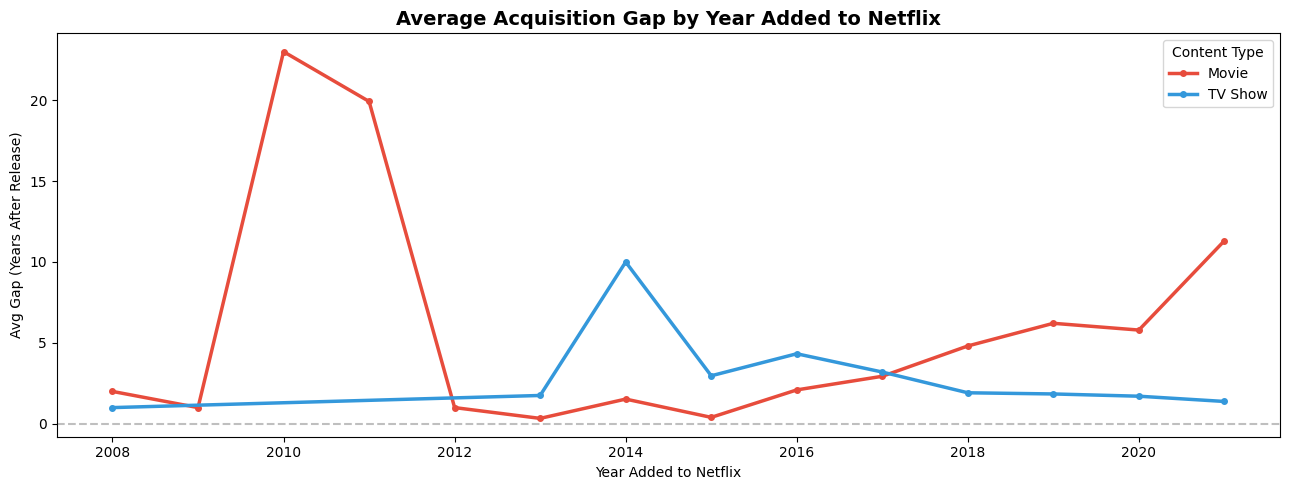

In [39]:
avg_gap = (
    df_gap.groupby(['year_added', 'type'])['acquisition_gap']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

for content_type, color in zip(['Movie', 'TV Show'], ['#e74c3c', '#3498db']):
    subset = avg_gap[avg_gap['type'] == content_type]
    ax.plot(subset['year_added'], subset['acquisition_gap'],
            label=content_type, color=color,
            linewidth=2.5, marker='o', markersize=4)

ax.set_title('Average Acquisition Gap by Year Added to Netflix', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year Added to Netflix')
ax.set_ylabel('Avg Gap (Years After Release)')
ax.legend(title='Content Type')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

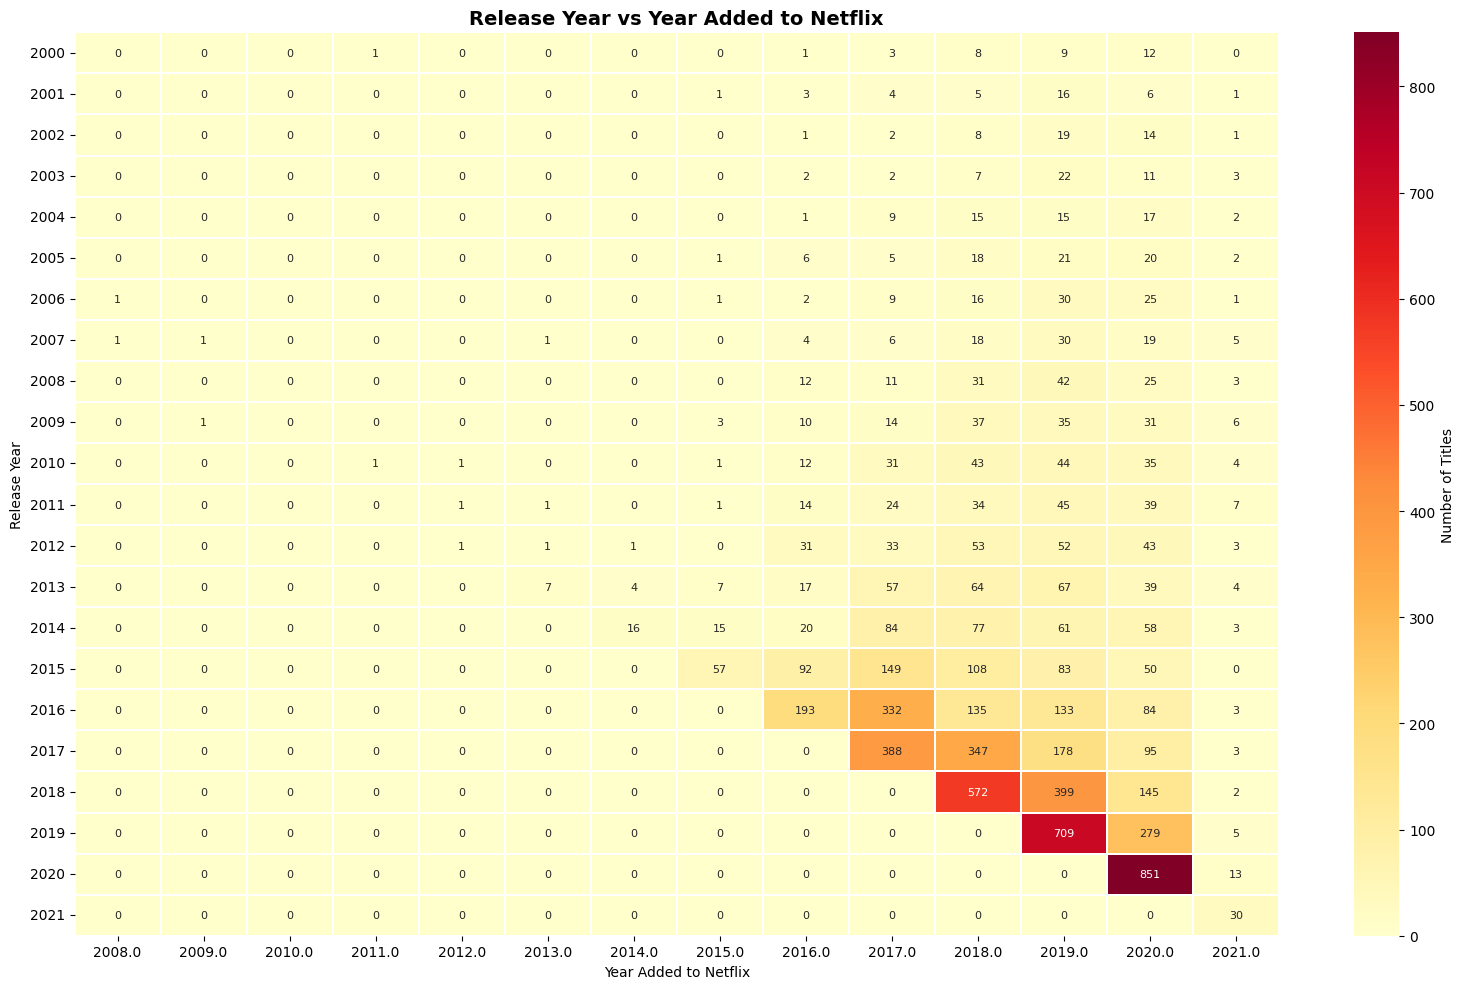

In [43]:
# Count titles per release_year × year_added combination
heatmap_data = (
    df_gap.groupby(['release_year', 'year_added'])
    .size()
    .unstack(fill_value=0)
)

# Filter to readable range
heatmap_data = heatmap_data.loc[2000:2021, 2008:2021]

plt.figure(figsize=(16, 10))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.2,
    annot=True,          # ✅ Show values inside each cell
    fmt='d',             # ✅ Format as integers (whole numbers)
    annot_kws={'size': 8},  # ✅ Keep font small so numbers fit
    cbar_kws={'label': 'Number of Titles'}
)

plt.title('Release Year vs Year Added to Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Release Year')
plt.tight_layout()
plt.show()

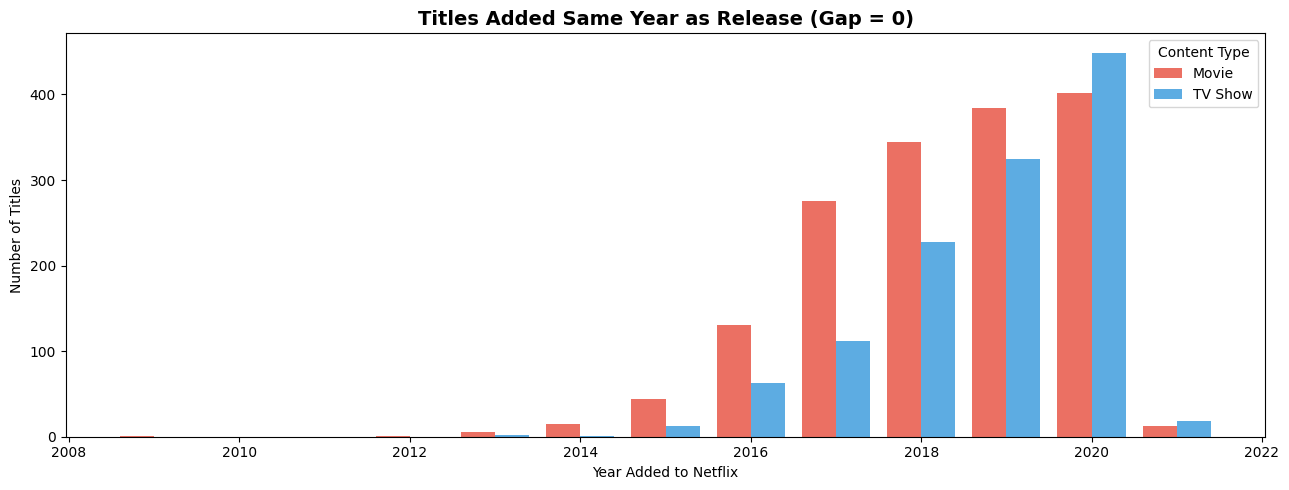

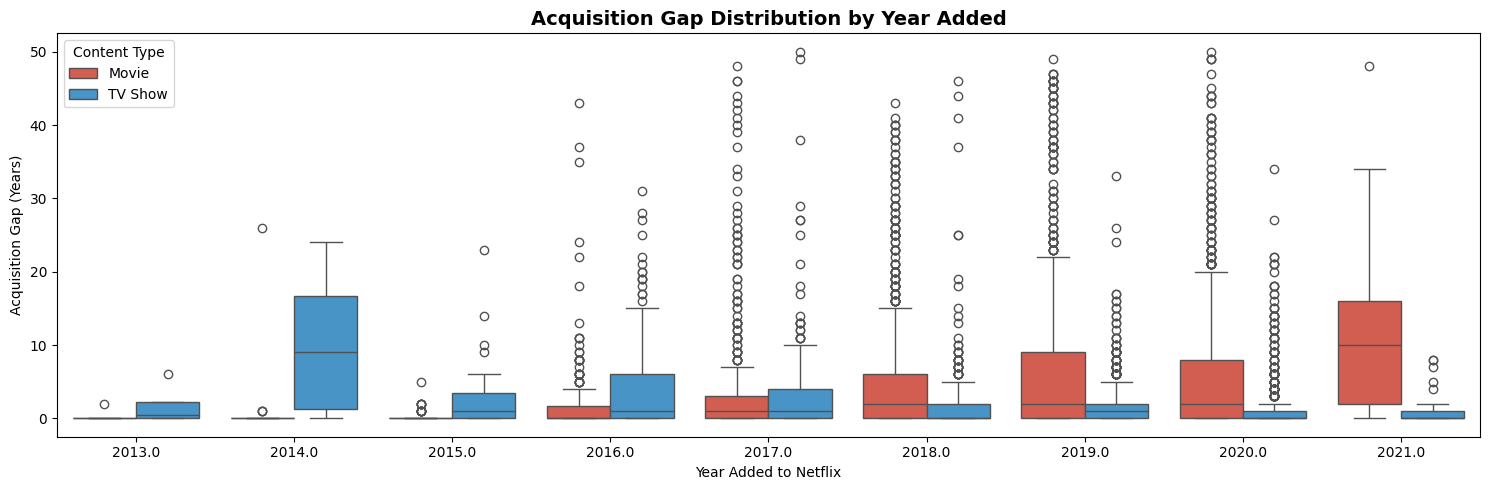

In [42]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.boxplot(
    data=df_gap[df_gap['year_added'] >= 2013],
    x='year_added',
    y='acquisition_gap',
    hue='type',
    palette=['#e74c3c', '#3498db'],
    ax=ax
)

ax.set_title('Acquisition Gap Distribution by Year Added', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year Added to Netflix')
ax.set_ylabel('Acquisition Gap (Years)')
ax.legend(title='Content Type')
plt.tight_layout()
plt.show()

## 📊 Insight: Release Year vs Year Added to Netflix

### Feature Engineering
- **`year_added`** → Extracted from `date_added` column
- **`acquisition_gap`** → `year_added − release_year`  
  Represents how many years after production Netflix acquired the title.
  - `gap = 0` → Added same year as release (**likely a Netflix Original**)
  - `gap > 5` → Older/archival content licensed to the platform

---

### Key Findings

- **Gap is shrinking over time** — The average acquisition gap has 
  steadily decreased since 2015, meaning Netflix is increasingly 
  acquiring **fresher content** closer to its release date.

- **Movies have a larger gap than TV Shows** — Movies on Netflix 
  tend to be older acquisitions, while TV Shows are more recent — 
  consistent with the earlier content age analysis.

- **Gap = 0 titles are surging post-2015** — The number of titles 
  added in the same year as their release has grown sharply, 
  directly reflecting the **Netflix Originals explosion**.

- **Diagonal pattern in heatmap** — The Release Year vs Year Added 
  heatmap shows a clear diagonal forming in recent years, confirming 
  Netflix is transitioning from a **back-catalog library** to a 
  **fresh content platform**.

---

### 🔑 Key Takeaway
> Netflix has fundamentally shifted its strategy — from licensing 
> **old, archived content** to producing and acquiring 
> **fresh, original content** released directly on the platform. 
> The acquisition gap shrinking to near **zero post-2016** is the 
> clearest evidence of this transformation.